***Estrutucuración del proyecto***

*Instalar y desplegar librerias*

In [2]:
!pip install pandas openpyxl scikit-learn matplotlib seaborn plotly jupyter


  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached plotly-6.6.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached notebook-7.5.5-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.0-py3-none-any.whl.metadata (8.4 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab-4.5.6-py3-none-any.whl.metadata (16 kB)
  Using cached async_lru-2.2.0-py3-none-any.whl.metadata (7.2 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jupyter_lsp-2.3.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyter_server-2.17.0-py3-none-any.whl.metadata (8.5 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\andre\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
# Manejo de datos
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path
# Utilidades
import warnings
warnings.filterwarnings('ignore')


*Leer archivos*

In [2]:
from pathlib import Path
import pandas as pd

carpeta = Path(r"C:\Users\andre\OneDrive - Universidad de los Andes\cosas de la universidad\Uniandes\VII\PICE\iPPO\Productos")
meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
         "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
años = ["2024", "2025", "2026"]

productos = {}
for año in años:
    for mes in meses:
        archivo = f"{mes}-{año}.xlsx"
        ruta = carpeta / archivo
        if not ruta.exists():
            print(f"No encontrado: {archivo}")
            continue
        try:
            df = pd.read_excel(ruta, header=7)
            productos[f"{mes}-{año}"] = df
        except PermissionError:
            print(f"Permiso denegado (¿está abierto en Excel?): {archivo}")
            continue

carpeta_2 = Path(r"C:\Users\andre\OneDrive - Universidad de los Andes\cosas de la universidad\Uniandes\VII\PICE\iPPO\Facturas_lugar")
lugares = ["CP", "Principal"]

factura_lugar = {}
for año in años:
    for lugar in lugares:
        archivo = f"{lugar}-{año}.xlsx"
        ruta = carpeta_2 / archivo
        if not ruta.exists():
            print(f"No encontrado: {archivo}")
            continue
        try:
            df = pd.read_excel(ruta, header=6)
            factura_lugar[f"{lugar}-{año}"] = df
        except PermissionError:
            print(f"Permiso denegado (¿está abierto en Excel?): {archivo}")
            continue

print("Productos cargados:", list(productos.keys()))
print("Facturas lugar cargadas:", list(factura_lugar.keys()))


No encontrado: Enero-2024.xlsx
No encontrado: Febrero-2024.xlsx
No encontrado: Marzo-2024.xlsx
No encontrado: Abril-2024.xlsx
No encontrado: Mayo-2024.xlsx
No encontrado: Junio-2024.xlsx
No encontrado: Julio-2024.xlsx
No encontrado: Marzo-2026.xlsx
No encontrado: Abril-2026.xlsx
No encontrado: Mayo-2026.xlsx
No encontrado: Junio-2026.xlsx
No encontrado: Julio-2026.xlsx
No encontrado: Agosto-2026.xlsx
No encontrado: Septiembre-2026.xlsx
No encontrado: Octubre-2026.xlsx
No encontrado: Noviembre-2026.xlsx
No encontrado: Diciembre-2026.xlsx
No encontrado: CP-2024.xlsx
No encontrado: Principal-2024.xlsx
No encontrado: CP-2026.xlsx
No encontrado: Principal-2026.xlsx
Productos cargados: ['Agosto-2024', 'Septiembre-2024', 'Octubre-2024', 'Noviembre-2024', 'Diciembre-2024', 'Enero-2025', 'Febrero-2025', 'Marzo-2025', 'Abril-2025', 'Mayo-2025', 'Junio-2025', 'Julio-2025', 'Agosto-2025', 'Septiembre-2025', 'Octubre-2025', 'Noviembre-2025', 'Diciembre-2025', 'Enero-2026', 'Febrero-2026']
Facturas 

*Verificar fechas de los acrhivos*

In [19]:
col_fecha = "Fecha elaboración"
for mes, df in productos.items():
    df[col_fecha] = pd.to_datetime(df[col_fecha], dayfirst=True, errors="coerce")
    inicio = df[col_fecha].min()
    fin = df[col_fecha].max()
    print(f"{mes}: {inicio.date()} → {fin.date()}")



Agosto-2024: 2024-08-03 → 2024-08-30
Septiembre-2024: 2024-09-06 → 2024-09-24
Octubre-2024: 2024-10-04 → 2024-10-21
Noviembre-2024: 2024-11-25 → 2024-11-25
Diciembre-2024: 2024-12-04 → 2024-12-12
Enero-2025: 2025-01-08 → 2025-01-31
Febrero-2025: 2025-02-01 → 2025-02-28
Marzo-2025: 2025-03-02 → 2025-03-31
Abril-2025: 2025-04-01 → 2025-04-30
Mayo-2025: 2025-05-01 → 2025-05-31
Junio-2025: 2025-06-03 → 2025-06-30
Julio-2025: 2025-07-01 → 2025-07-31
Agosto-2025: 2025-08-04 → 2025-08-31
Septiembre-2025: 2025-09-01 → 2025-09-30
Octubre-2025: 2025-10-01 → 2025-10-31
Noviembre-2025: 2025-11-04 → 2025-11-30
Diciembre-2025: 2025-12-01 → 2025-12-31
Enero-2026: 2026-01-07 → 2026-01-31
Febrero-2026: 2026-02-02 → 2026-02-28


*Crear un df unificado*

In [20]:
df_total = pd.concat(productos.values(), ignore_index=True)


*Concatenar df de ventas por lugar*

In [51]:

#Concatenar en caso de tener mas datos
CP_df=factura_lugar["CP-2025"]
Principal_df=factura_lugar["Principal-2025"]

#Poner el lugar en cada df
CP_df["Lugar"]="CP"
Principal_df["Lugar"]="Principal"

#Unificar todo en un solo df
df_place=pd.concat([CP_df,Principal_df],ignore_index=True)



*Ver que datos tiene cada df*

In [22]:
col1=set(df_total.columns)
col2=set(df_place.columns)

#Mirar intersescciones
print(col1 - col2)#Esta en  total
print(col2 - col1)#Esta en places
print(col2 & col1)#Esta en ambos


{'Fecha creación', 'Valor desc.', 'Forma pago', 'Impuesto Cargo 2', 'Número comprobante', 'Nombre contacto', 'Valor Impuesto Cargo 2', 'Fecha modificación', 'Referencia fábrica', 'Nombre tercero', 'Cantidad', 'Centro costo', 'Valor unitario', 'Factura proveedor', 'Consecutivo', 'Impuesto cargo', 'Correo electrónico', 'Valor Impuesto Retención', 'Valor Impuesto Cargo', 'Tipo de registro', 'Identificación Vendedor', 'Descuento en totales', 'Tipo clasificación', 'Tasa de cambio', 'Base retención (ICA/IVA)', 'Bodega', 'Fecha elaboración', 'Cargo en totales', 'Impuesto retención', 'Fecha vencimiento', 'Código', 'Tipo transacción', 'Nombre vendedor', 'Nombre', 'Observaciones', 'Sucursal', 'Identificación', 'Base AIU'}
{'Vendedor', 'Nro. de comprobante', 'Tipo de comprobante', 'Estado', 'Cliente', 'Tarjetas', 'Otros', 'Lugar', 'Turno', 'Nro. de identificación', 'LUgar', 'Fecha y hora', 'Efectivo', 'Crédito', 'Pagos en línea'}
{'Total'}


*Adaptar datos por factura*

In [53]:
#Ventas
df_ventas_producto=df_total[df_total["Tipo transacción"]=="Factura de venta"]
df_ventas_producto = df_ventas_producto.reset_index(drop=True)

variables_iniciales=["Consecutivo","Fecha creación","Tipo de registro","Tipo clasificación","Código","Nombre","Nombre vendedor",\
                     "Cantidad","Valor unitario","Valor Impuesto Cargo","Total","Forma pago","Número comprobante"]
df_ventas_producto_filtrado=df_ventas_producto[variables_iniciales]

df_ventas_producto_filtrado['Establecimiento'] = df_ventas_producto_filtrado['Número comprobante'].map({'FV-1': 'Principal',"FV-2":"Eventos","FV-3":"Principal",'FV-4': 'CP'})

#Compras
df_compras_producto=df_total[df_total["Tipo transacción"]=="Factura de compra"]
variables_compras=["Consecutivo","Factura proveedor","Identificación","Nombre tercero","Fecha creación","Fecha modificación","Fecha elaboración","Nombre contacto"\
    ,"Tipo de registro","Tipo clasificación","Código","Nombre","Cantidad","Valor unitario","Total","Forma pago","Fecha vencimiento"]

df_compras_producto_filtrado=df_compras_producto[variables_compras]


*Poner fecha en formato datetime*

In [54]:

df_ventas_producto_filtrado['Fecha creación'] = pd.to_datetime(df_ventas_producto_filtrado
                                                               ['Fecha creación'], format='%d/%m/%Y')

fechas = ["Fecha creación", "Fecha modificación", "Fecha elaboración", "Fecha vencimiento"]
df_compras_producto_filtrado[fechas] = df_compras_producto_filtrado[fechas].apply(
    pd.to_datetime, format='%d/%m/%Y'
)


*Poner como se pago cada transacción y otras cosas*

In [55]:
#Poner el tipo de transacción de cda fila 
df_ventas_producto_filtrado["Forma pago"]=df_ventas_producto_filtrado["Forma pago"].bfill()
df_compras_producto_filtrado["Forma pago"]=df_compras_producto_filtrado["Forma pago"].bfill()
#Eliminar las filas que hacian referencia al metodo de pago
df_ventas_producto_filtrado.dropna(subset=["Código"],inplace=True)
df_compras_producto_filtrado.dropna(subset=["Código"],inplace=True)


In [10]:
df_compras_producto_filtrado


,Consecutivo,Factura proveedor,Identificación,Nombre tercero,Fecha creación,Fecha modificación,Fecha elaboración,Nombre contacto,Tipo de registro,Tipo clasificación,Código,Nombre,Cantidad,Valor unitario,Total,Forma pago,Fecha vencimiento
159,40.0,FC-948,1.110521e+09,Nelson ferney Quiroga gomez,2024-08-23,NaT,2024-08-23,Nelson Quiroga,Secuencia,Producto,F&V01,Aguacate,2000.0,13.5,27000.0,Bancolombia cta cte,2024-08-23
160,40.0,FC-948,1.110521e+09,Nelson ferney Quiroga gomez,2024-08-23,NaT,2024-08-23,Nelson Quiroga,Secuencia,Producto,F&V05,Camote,1000.0,11.0,11000.0,Bancolombia cta cte,2024-08-23
162,41.0,FC-954,1.110521e+09,Nelson ferney Quiroga gomez,2024-08-23,NaT,2024-08-23,Nelson Quiroga,Secuencia,Producto,F&V01,Aguacate,7000.0,9.0,63000.0,Bancolombia cta cte,2024-08-23
164,42.0,FC-953,1.110521e+09,Nelson ferney Quiroga gomez,2024-08-23,NaT,2024-08-23,Nelson Quiroga,Secuencia,Producto,F&V01,Aguacate,2000.0,9.0,18000.0,Bancolombia cta cte,2024-08-23
165,42.0,FC-953,1.110521e+09,Nelson ferney Quiroga gomez,2024-08-23,NaT,2024-08-23,Nelson Quiroga,Secuencia,Producto,F&V05,Camote,1000.0,12.0,12000.0,Bancolombia cta cte,2024-08-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28698,704.0,FC-2,1.019147e+09,LAURA SOFIA ROMERO CORTES,2026-03-11,NaT,2026-02-25,LAURA SOFIA ROMERO CORTES,Secuencia,Gasto,739545,TRANSPORTES URBANOS,1.0,145000.0,145000.0,Efectivo,2026-02-25
28704,729.0,FC-2,8.110253e+08,NOVAVENTAS SAS,2026-03-11,NaT,2026-02-25,NOVAVENTAS SAS,Secuencia,Gasto,739595,Otros Indirectos,1.0,122500.0,122500.0,Efectivo,2026-02-25
28708,706.0,FC-2,3.978233e+07,Alejandra Vallejo,2026-03-11,2026-03-11,2026-02-24,Alejandra Vallejo,Secuencia,Gasto,739545,TRANSPORTES URBANOS,1.0,83600.0,83600.0,Efectivo,2026-02-24
28721,702.0,FC-2,1.019147e+09,LAURA SOFIA ROMERO CORTES,2026-03-11,NaT,2026-02-18,LAURA SOFIA ROMERO CORTES,Secuencia,Gasto,739545,TRANSPORTES URBANOS,1.0,3600.0,3600.0,Efectivo,2026-02-18


In [56]:
df_ventas_producto_filtrado.drop(columns=["Tipo de registro","Tipo clasificación"],inplace=True)


In [57]:
ventas=df_ventas_producto_filtrado
ventas.rename(columns={"Fecha creación":"Fecha"},inplace=True)
ventas


,Consecutivo,Fecha,Código,Nombre,Nombre vendedor,Cantidad,Valor unitario,Valor Impuesto Cargo,Total,Forma pago,Número comprobante,Establecimiento
0,401.0,2024-08-30,11,Sándwich o pockets (Mini chef),Tatiana Perez,1.0,12962.96,1037.04,14000.0,Tarjeta Débito,FV-1,Principal
1,401.0,2024-08-30,28,Ensalada Pollo miel mostaza Mediana,Tatiana Perez,1.0,18518.52,1481.48,20000.0,Tarjeta Débito,FV-1,Principal
2,401.0,2024-08-30,38,Arma tu plato mediano (18k),Tatiana Perez,1.0,20370.37,1629.63,22000.0,Tarjeta Débito,FV-1,Principal
3,401.0,2024-08-30,66,Pancakes chocolate,Tatiana Perez,1.0,8888.89,711.11,9600.0,Tarjeta Débito,FV-1,Principal
5,402.0,2024-08-30,B0002,Agua cristal,Tatiana Perez,1.0,2777.78,222.22,3000.0,Efectivo,FV-1,Principal
...,...,...,...,...,...,...,...,...,...,...,...,...
32080,896.0,2026-02-02,16,Bowl Colombianito Mediana,Juan Jose Yara Vallejo,1.0,19444.44,1555.56,21000.0,Nequí,FV-4,CP
32081,896.0,2026-02-02,27,Ensalada Chefsito Grande,Juan Jose Yara Vallejo,1.0,22222.22,1777.78,24000.0,Nequí,FV-4,CP
32082,896.0,2026-02-02,79,Americano Mediano,Juan Jose Yara Vallejo,2.0,4166.66,666.67,9000.0,Nequí,FV-4,CP
32083,896.0,2026-02-02,21025,Mexi,Juan Jose Yara Vallejo,1.0,18500.00,0.00,18500.0,Nequí,FV-4,CP


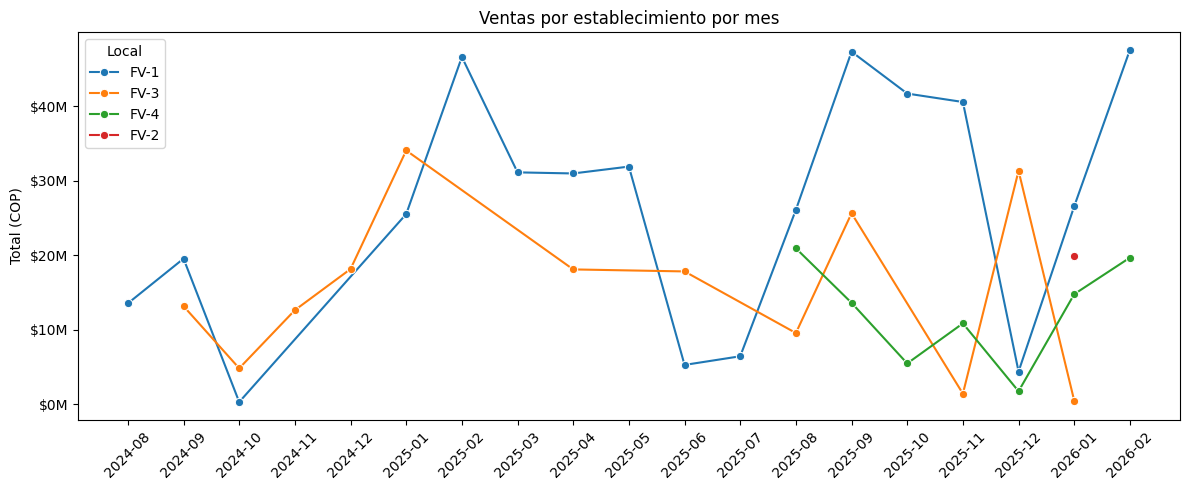

In [28]:
ventas["Periodo"] = pd.to_datetime(ventas["Fecha"]).dt.to_period("M")

resumen = (
    ventas
    .groupby(["Periodo", "Número comprobante"])["Total"]
    .sum()
    .reset_index()
)

resumen["Periodo"] = resumen["Periodo"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=resumen,
    x="Periodo",
    y="Total",
    hue="Número comprobante",
    marker="o"              # ← agrega puntos en cada mes
)
plt.xticks(rotation=45)
plt.title("Ventas por establecimiento por mes")
plt.ylabel("Total (COP)")
plt.xlabel("")
plt.legend(title="Local")  # ← título más claro en la leyenda

# Formato en millones en el eje Y
import matplotlib.ticker as mticker
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)

plt.tight_layout()
plt.show()


In [29]:
ventas["Periodo"] = pd.to_datetime(ventas["Fecha"]).dt.to_period("M")


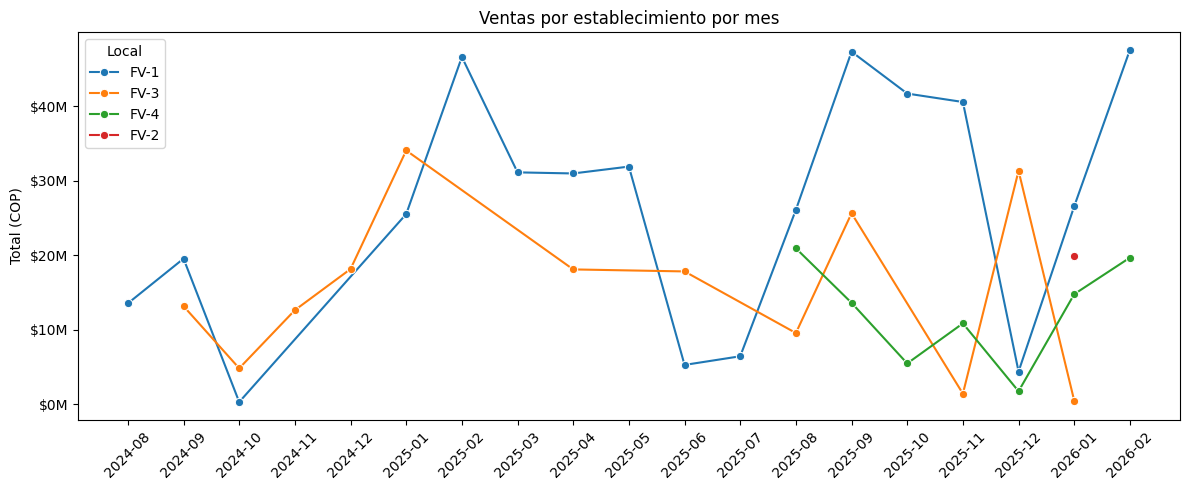

In [30]:

resumen = (
    ventas
    .groupby(["Periodo", "Número comprobante"])["Total"]
    .sum()
    .reset_index()
)

resumen["Periodo"] = resumen["Periodo"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=resumen,
    x="Periodo",
    y="Total",
    hue="Número comprobante",
    marker="o"              # ← agrega puntos en cada mes
)
plt.xticks(rotation=45)
plt.title("Ventas por establecimiento por mes")
plt.ylabel("Total (COP)")
plt.xlabel("")
plt.legend(title="Local")  # ← título más claro en la leyenda

# Formato en millones en el eje Y
import matplotlib.ticker as mticker
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)

plt.tight_layout()
plt.show()


In [ ]:
print(resumen)


    Periodo Número comprobante        Total
0   2024-08               FV-1  13552500.00
1   2024-09               FV-1  19548330.00
2   2024-09               FV-3  13178980.00
3   2024-10               FV-1    326500.00
4   2024-10               FV-3   4847800.00
5   2024-11               FV-3  12644600.00
6   2024-12               FV-3  18159161.00
7   2025-01               FV-1  25526797.17
8   2025-01               FV-3  34050200.00
9   2025-02               FV-1  46580484.50
10  2025-03               FV-1  31114572.00
11  2025-04               FV-1  30967700.00
12  2025-04               FV-3  18103340.40
13  2025-05               FV-1  31888620.00
14  2025-06               FV-1   5300000.00
15  2025-06               FV-3  17834199.26
16  2025-07               FV-1   6460500.00
17  2025-08               FV-1  26095890.00
18  2025-08               FV-3   9577060.00
19  2025-08               FV-4  20930765.00
20  2025-09               FV-1  47291960.00
21  2025-09               FV-3  

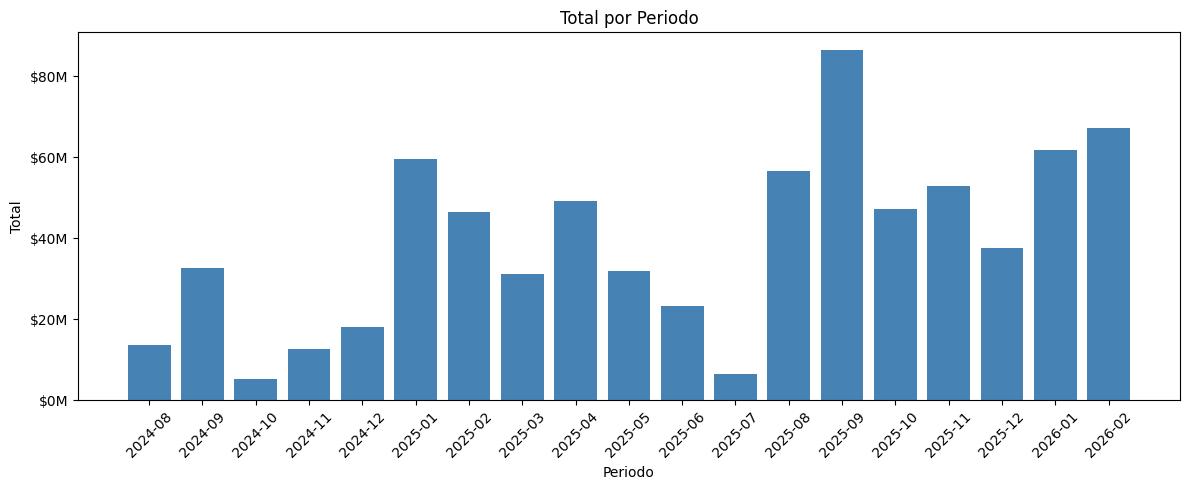

In [32]:
resumen_mes = (
    ventas
    .groupby("Periodo")["Total"]
    .sum()
    .reset_index()
)
resumen_mes["Periodo"] = resumen_mes["Periodo"].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(resumen_mes["Periodo"], resumen_mes["Total"], color="steelblue")
plt.title("Total por Periodo")
plt.xlabel("Periodo")
plt.ylabel("Total")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.tight_layout()
plt.show()


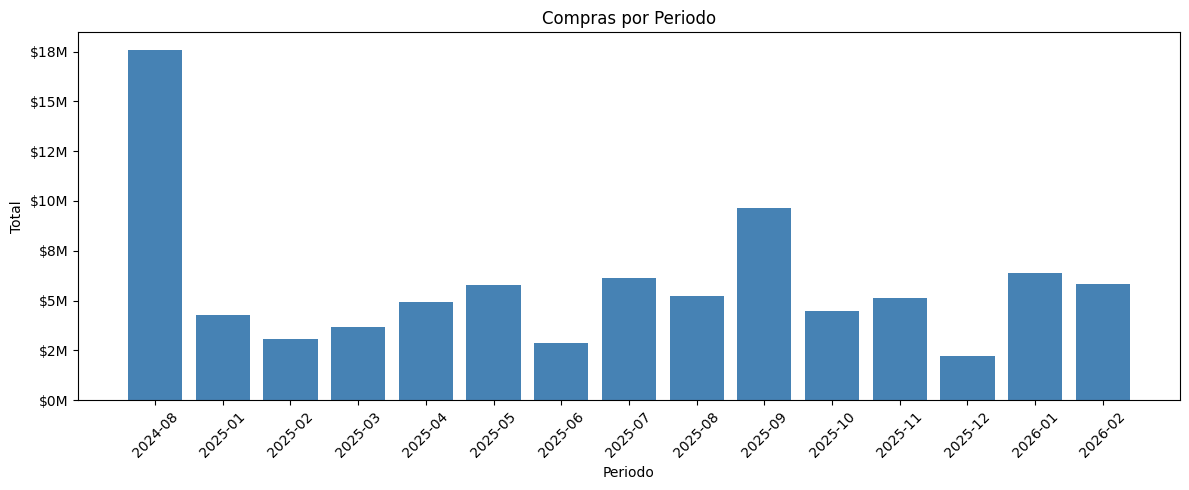

In [33]:
compras = df_compras_producto_filtrado.copy()
compras["Periodo"] = pd.to_datetime(compras["Fecha elaboración"]).dt.to_period("M")

resumen_compras_mes = compras.groupby("Periodo")["Total"].sum().reset_index()
resumen_compras_mes["Periodo"] = resumen_compras_mes["Periodo"].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(resumen_compras_mes["Periodo"], resumen_compras_mes["Total"], color="steelblue")
plt.title("Compras por Periodo")
plt.xlabel("Periodo")
plt.ylabel("Total")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.tight_layout()
plt.show()


In [ ]:
ventas_compras = resumen_mes.merge(
    resumen_compras_mes, 
    on="Periodo", 
    how="outer",
    suffixes=("_ventas", "_compras")
)

ventas_compras = ventas_compras.fillna(0)
ventas_compras["Utilidad"] = ventas_compras["Total_ventas"] - ventas_compras["Total_compras"]
ventas_compras = ventas_compras.sort_values("Periodo").reset_index(drop=True)

print(ventas_compras[["Periodo", "Total_ventas", "Total_compras", "Utilidad"]])


    Periodo  Total_ventas  Total_compras     Utilidad
0   2024-08   13552500.00     17591988.0  -4039488.00
1   2024-09   32727310.00            0.0  32727310.00
2   2024-10    5174300.00            0.0   5174300.00
3   2024-11   12644600.00            0.0  12644600.00
4   2024-12   18159161.00            0.0  18159161.00
5   2025-01   59576997.17      4249653.0  55327344.17
6   2025-02   46580484.50      3089645.0  43490839.50
7   2025-03   31114572.00      3692100.0  27422472.00
8   2025-04   49071040.40      4949213.0  44121827.40
9   2025-05   31888620.00      5764664.0  26123956.00
10  2025-06   23134199.26      2863814.0  20270385.26
11  2025-07    6460500.00      6150784.0    309716.00
12  2025-08   56603715.00      5242819.0  51360896.00
13  2025-09   86547085.00      9624248.0  76922837.00
14  2025-10   47174155.00      4496786.0  42677369.00
15  2025-11   52863172.00      5109383.0  47753789.00
16  2025-12   37505122.90      2227879.0  35277243.90
17  2026-01   61709036.00   

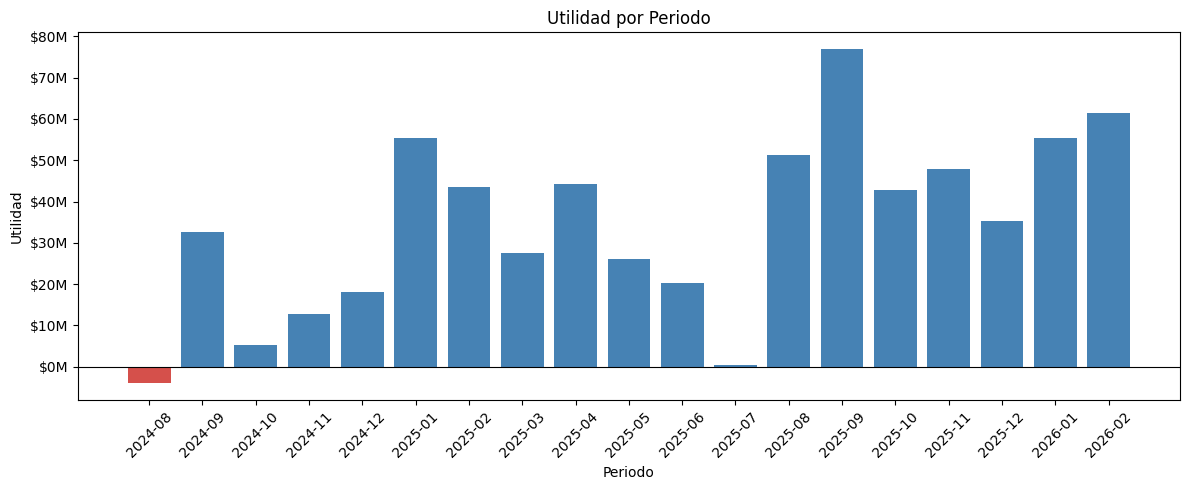

In [ ]:
plt.figure(figsize=(12, 5))
plt.bar(ventas_compras["Periodo"], ventas_compras["Utilidad"], 
        color=["#d5504b" if x < 0 else "steelblue" for x in ventas_compras["Utilidad"]])
plt.title("Utilidad por Periodo")
plt.xlabel("Periodo")
plt.ylabel("Utilidad")
plt.xticks(rotation=45)
plt.axhline(y=0, color="black", linewidth=0.8)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.tight_layout()
plt.show()


In [ ]:
ventas_f1 = ventas[ventas["Número comprobante"] == "FV-1"].reset_index()


In [ ]:
ventas_f2 = ventas[ventas["Número comprobante"] == "FV-2"].reset_index()


In [ ]:
ventas_f3 = ventas[ventas["Número comprobante"] == "FV-3"].reset_index()


In [ ]:
ventas_f4 = ventas[ventas["Número comprobante"] == "FV-4"].reset_index()


**